In [9]:
import pandas as pd

# Load the true CSV file
file_name = 'Sales Transaction.csv'
df = pd.read_csv(file_name, encoding='ISO-8859-1', low_memory=False)

# Check if it loaded correctly
print(f"Dataset loaded! Total rows: {df.shape[0]}")
df.head()

Dataset loaded! Total rows: 536350


,ï»¿TransactionNo,Date,ProductNo,ProductName,Price,Quantity,CustomerNo,Country
0,581482,12-09-2019,22485,Set Of 2 Wooden Market Crates,21.47,12,17490.0,United Kingdom
1,581475,12-09-2019,22596,Christmas Star Wish List Chalkboard,10.65,36,13069.0,United Kingdom
2,581475,12-09-2019,23235,Storage Tin Vintage Leaf,11.53,12,13069.0,United Kingdom
3,581475,12-09-2019,23272,Tree T-Light Holder Willie Winkie,10.65,12,13069.0,United Kingdom
4,581475,12-09-2019,23239,Set Of 4 Knick Knack Tins Poppies,11.94,6,13069.0,United Kingdom


In [10]:
# Remove any leading/trailing spaces from column names
df.columns = df.columns.str.strip()

# Print the clean column names to verify
print(df.columns)

Index(['ï»¿TransactionNo', 'Date', 'ProductNo', 'ProductName', 'Price',
       'Quantity', 'CustomerNo', 'Country'],
      dtype='str')


In [11]:
# Force conversion and turn bad dates into NaT (Not a Time)
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# Drop rows where the date couldn't be converted
df = df.dropna(subset=['Date'])

# Now create your Year and Month columns
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

print("Date conversion complete! Any invalid dates were removed.")
print(f"Remaining rows: {len(df)}")


Date conversion complete! Any invalid dates were removed.
Remaining rows: 230646


In [12]:
# Show 10 random rows to verify the new columns
df.sample(10)

# See where the missing data is
print("Missing values per column:")
print(df.isnull().sum())

# Count how many rows exist for each year
print(df['Year'].value_counts())

Missing values per column:
ï»¿TransactionNo     0
Date                 0
ProductNo            0
ProductName          0
Price                0
Quantity             0
CustomerNo          27
Country              0
Year                 0
Month                0
dtype: int64
Year
2019    204178
2018     26468
Name: count, dtype: int64


In [13]:
# 1. Remove rows where Price or Quantity is missing
import pandas as pd

df = pd.read_csv("Sales Transaction.csv")
print(df.head())

df = df.dropna(subset=['Price', 'Quantity'])

df_clean = df[df['Quantity'] > 0].copy()

df_clean['Total_Sales'] = df_clean['Price'] * df_clean['Quantity']

print(df_clean.head())

  TransactionNo        Date ProductNo                          ProductName  \
0        581482  12-09-2019     22485        Set Of 2 Wooden Market Crates   
1        581475  12-09-2019     22596  Christmas Star Wish List Chalkboard   
2        581475  12-09-2019     23235             Storage Tin Vintage Leaf   
3        581475  12-09-2019     23272    Tree T-Light Holder Willie Winkie   
4        581475  12-09-2019     23239    Set Of 4 Knick Knack Tins Poppies   

   Price  Quantity  CustomerNo         Country  
0  21.47        12     17490.0  United Kingdom  
1  10.65        36     13069.0  United Kingdom  
2  11.53        12     13069.0  United Kingdom  
3  10.65        12     13069.0  United Kingdom  
4  11.94         6     13069.0  United Kingdom  
  TransactionNo        Date ProductNo                          ProductName  \
0        581482  12-09-2019     22485        Set Of 2 Wooden Market Crates   
1        581475  12-09-2019     22596  Christmas Star Wish List Chalkboard   
2  

In [14]:
#Remove Invalid Quantities
df_clean = df[df['Quantity'] > 0].copy()

In [15]:
#Create Total Sales KPI
df_clean['Total_Sales'] = df_clean['Price'] * df_clean['Quantity']

In [16]:
#Check Dataset Info
print(df_clean.info())


<class 'pandas.DataFrame'>
Index: 527765 entries, 0 to 536324
Data columns (total 9 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   TransactionNo  527765 non-null  str    
 1   Date           527765 non-null  str    
 2   ProductNo      527765 non-null  str    
 3   ProductName    527765 non-null  str    
 4   Price          527765 non-null  float64
 5   Quantity       527765 non-null  int64  
 6   CustomerNo     527764 non-null  float64
 7   Country        527765 non-null  str    
 8   Total_Sales    527765 non-null  float64
dtypes: float64(3), int64(1), str(5)
memory usage: 40.3 MB
None


In [17]:
#Generate Basic KPIs
#Total Revenue
print("Total Revenue:", df_clean['Total_Sales'].sum())
#Total Orders
print("Total Orders:", df_clean.shape[0])
#Average Sales
print("Average Sales:", df_clean['Total_Sales'].mean())
#For top selling products
top_products = df_clean.groupby('ProductName')['Total_Sales'].sum().sort_values(ascending=False)
print(top_products.head(10))

Total Revenue: 62965974.339999996
Total Orders: 527765
Average Sales: 119.30683986243876
ProductName
Paper Craft Little Birdie             1002718.10
Medium Ceramic Top Storage Jar         881990.18
Popcorn Holder                         587433.94
World War 2 Gliders Asstd Designs      569735.39
Cream Hanging Heart T-Light Holder     484592.69
Assorted Colour Bird Ornament          421318.74
Pack Of 72 Retrospot Cake Cases        391485.03
Rabbit Night Light                     329029.89
Regency Cakestand 3 Tier               307483.85
Jumbo Bag Red Retrospot                297205.04
Name: Total_Sales, dtype: float64


In [18]:
df_clean['Date'] = pd.to_datetime(df_clean['Date'], errors='coerce')
print(df_clean['Date'].head())
print(df_clean['Date'].dtype)

0   2019-12-09
1   2019-12-09
2   2019-12-09
3   2019-12-09
4   2019-12-09
Name: Date, dtype: datetime64[us]
datetime64[us]


In [19]:
#Daily monthly_sales
daily_sales = df_clean.groupby(df_clean['Date'].dt.date)['Total_Sales'].sum()
print(daily_sales.head())

#monthly sales
monthly_sales = df_clean.groupby(df_clean['Date'].dt.month)['Total_Sales'].sum()
print(monthly_sales)


Date
2018-12-01    326820.08
2018-12-02    367316.62
2018-12-03    206313.62
2018-12-05    197565.27
2018-12-06    273420.10
Name: Total_Sales, dtype: float64
Date
1.0     1528303.93
2.0     1242737.11
3.0     1492534.70
4.0     1414955.32
5.0     1971504.88
6.0     1682185.62
7.0     1524724.01
8.0     2230649.80
9.0     2126688.14
10.0    2914436.99
11.0    3498546.61
12.0    5143348.05
Name: Total_Sales, dtype: float64


In [20]:
product_revenue = df_clean.groupby('ProductName')['Total_Sales'].sum().sort_values(ascending=False)

print(product_revenue.head(10))

country_revenue = df_clean.groupby('Country')['Total_Sales'].sum().sort_values(ascending=False)

print(country_revenue.head(10))

ProductName
Paper Craft Little Birdie             1002718.10
Medium Ceramic Top Storage Jar         881990.18
Popcorn Holder                         587433.94
World War 2 Gliders Asstd Designs      569735.39
Cream Hanging Heart T-Light Holder     484592.69
Assorted Colour Bird Ornament          421318.74
Pack Of 72 Retrospot Cake Cases        391485.03
Rabbit Night Light                     329029.89
Regency Cakestand 3 Tier               307483.85
Jumbo Bag Red Retrospot                297205.04
Name: Total_Sales, dtype: float64
Country
United Kingdom    52524658.47
Netherlands        2151553.59
EIRE               1713410.95
Germany            1371543.27
France             1330652.89
Australia           995607.91
Sweden              401879.89
Switzerland         361969.25
Japan               293155.44
Spain               281012.27
Name: Total_Sales, dtype: float64


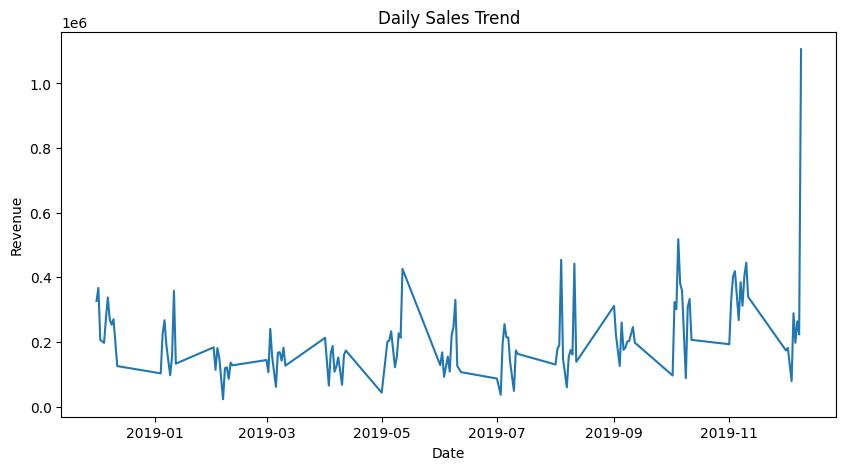

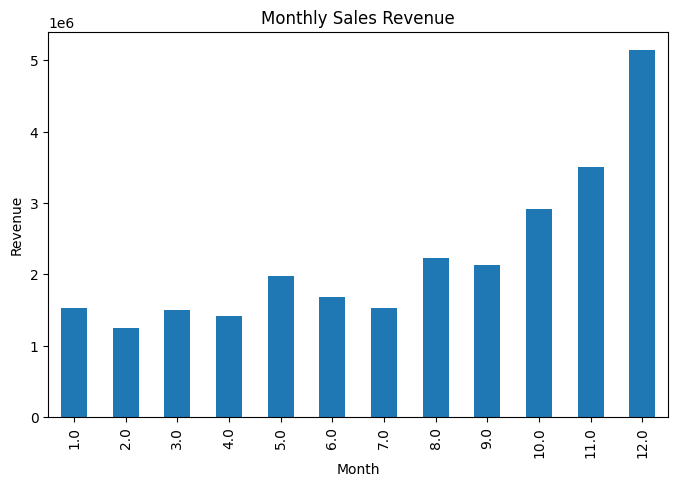

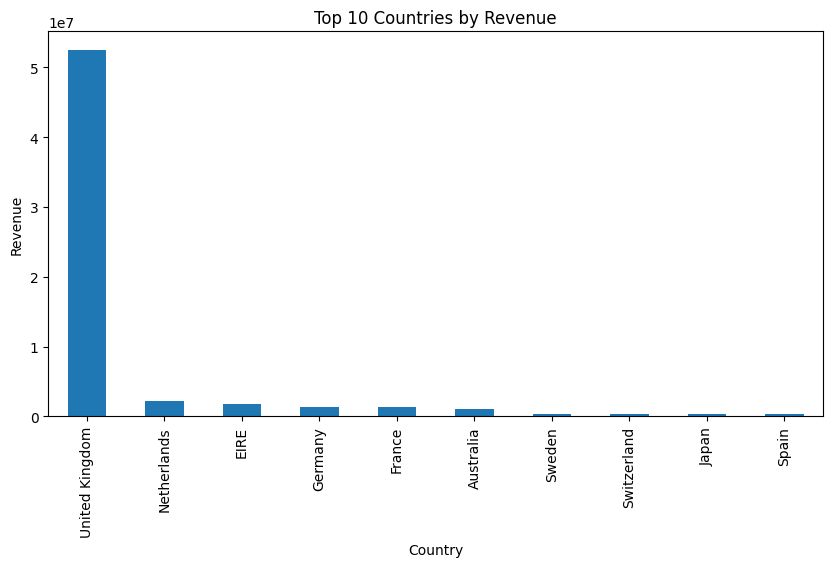

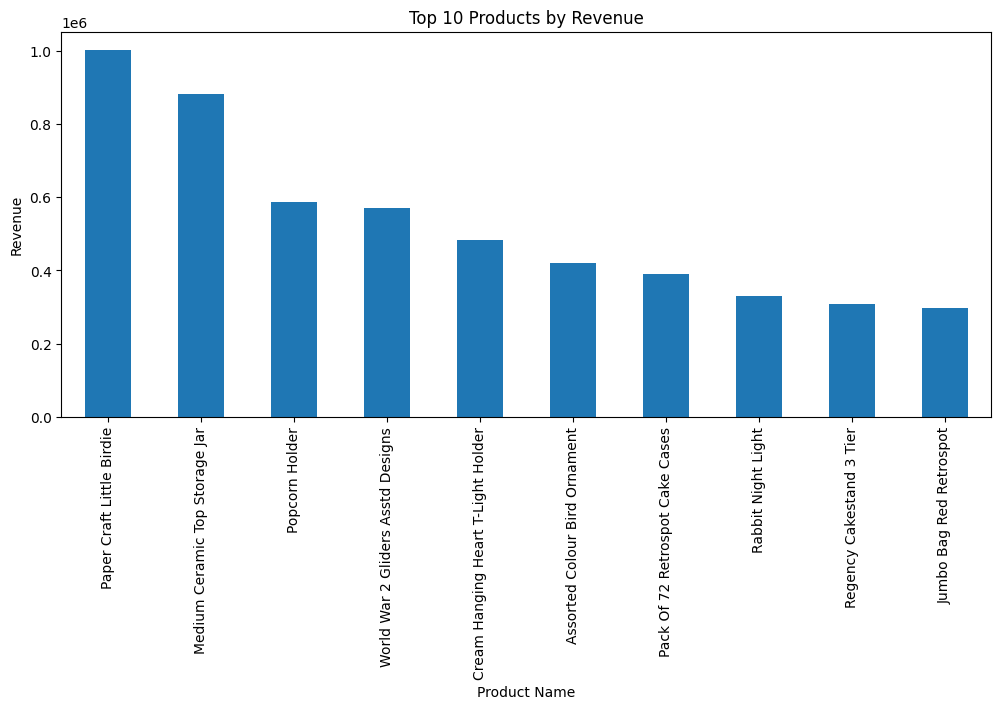

In [21]:
#charts
import matplotlib.pyplot as plt

#daily sales chart
daily_sales = df_clean.groupby(df_clean['Date'].dt.date)['Total_Sales'].sum()

daily_sales.plot(kind='line', figsize=(10,5))

plt.title("Daily Sales Trend")
plt.xlabel("Date")
plt.ylabel("Revenue")

plt.show()

#Monthly sales
monthly_sales = df_clean.groupby(df_clean['Date'].dt.month)['Total_Sales'].sum()

monthly_sales.plot(kind='bar', figsize=(8,5))

plt.title("Monthly Sales Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.show()

# Country-wise Revenue Chart
country_revenue = df_clean.groupby('Country')['Total_Sales'].sum().sort_values(ascending=False)

country_revenue.head(10).plot(kind='bar', figsize=(10,5))

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Country")
plt.ylabel("Revenue")

plt.show()

#Product-wise Revenue Chart
product_revenue = df_clean.groupby('ProductName')['Total_Sales'].sum().sort_values(ascending=False)

product_revenue.head(10).plot(kind='bar', figsize=(12,5))

plt.title("Top 10 Products by Revenue")
plt.xlabel("Product Name")
plt.ylabel("Revenue")

plt.show()

In [22]:
#Check Missing Values
print(df_clean.isnull().sum())

#Check Duplicate Rows
print("Duplicate Rows:", df_clean.duplicated().sum())
df_clean = df_clean.drop_duplicates()

#Check Negative Quantities
print((df_clean['Quantity'] < 0).sum())

#Check Negative Prices
print((df_clean['Price'] < 0).sum())
df_clean = df_clean[df_clean['Price'] > 0]

# Check Data Types
print(df_clean.dtypes)

#Dataset Summary
print(df_clean.describe())

# Final Shape Check
print(df_clean.shape)

# Final Dataset Preview
print(df_clean.head())

# Save Final Clean Dataset
df_clean.to_csv("cleaned_sales_data.csv", index=False)

TransactionNo         0
Date             301119
ProductNo             0
ProductName           0
Price                 0
Quantity              0
CustomerNo            1
Country               0
Total_Sales           0
dtype: int64
Duplicate Rows: 5163
0
0
TransactionNo               str
Date             datetime64[us]
ProductNo                   str
ProductName                 str
Price                   float64
Quantity                  int64
CustomerNo              float64
Country                     str
Total_Sales             float64
dtype: object
                             Date          Price       Quantity  \
count                      224372  522602.000000  522602.000000   
mean   2019-06-26 04:08:55.895744      12.637155      10.667487   
min           2018-12-01 00:00:00       5.130000       1.000000   
25%           2019-03-08 00:00:00      10.990000       1.000000   
50%           2019-07-08 00:00:00      11.940000       4.000000   
75%           2019-10-11 00:00:00      14.

In [23]:
# finally validation
print(df_clean.isnull().sum())

print("Duplicates:", df_clean.duplicated().sum())

print("Negative Quantity:", (df_clean['Quantity'] < 0).sum())

print("Negative Price:", (df_clean['Price'] < 0).sum())

TransactionNo         0
Date             298230
ProductNo             0
ProductName           0
Price                 0
Quantity              0
CustomerNo            1
Country               0
Total_Sales           0
dtype: int64
Duplicates: 0
Negative Quantity: 0
Negative Price: 0


In [24]:
df_clean.to_csv("cleaned_sales_data.csv", index=False)
import os
print(os.getcwd())
print(df_clean.head())

d:\operational kpi project mca
  TransactionNo       Date ProductNo                          ProductName  \
0        581482 2019-12-09     22485        Set Of 2 Wooden Market Crates   
1        581475 2019-12-09     22596  Christmas Star Wish List Chalkboard   
2        581475 2019-12-09     23235             Storage Tin Vintage Leaf   
3        581475 2019-12-09     23272    Tree T-Light Holder Willie Winkie   
4        581475 2019-12-09     23239    Set Of 4 Knick Knack Tins Poppies   

   Price  Quantity  CustomerNo         Country  Total_Sales  
0  21.47        12     17490.0  United Kingdom       257.64  
1  10.65        36     13069.0  United Kingdom       383.40  
2  11.53        12     13069.0  United Kingdom       138.36  
3  10.65        12     13069.0  United Kingdom       127.80  
4  11.94         6     13069.0  United Kingdom        71.64  


In [2]:
import pandas as pd

df = pd.read_csv("cleaned_sales_data.csv")

df.head()

df.shape

(522602, 9)

In [3]:
df['Date'] = pd.to_datetime(df['Date'])

df['Day'] = df['Date'].dt.day
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year

In [5]:
X = df[['Day', 'Month', 'Quantity', 'Price']]

y = df['Total_Sales']

In [ ]:
#sales prediction using linear regression
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [10]:
df.isnull().sum()
df = df.dropna()
X = df[['Day', 'Month', 'Quantity', 'Price']]

y = df['Total_Sales']

In [ ]:
#splitted model
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
#trained model
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [13]:
predictions = model.predict(X_test)

print(predictions[:10])

[ 28.95874177  18.89765065 308.19680746 114.81547038  -0.72057387
  25.3726276   11.40742425 137.534231   265.63359051  75.79131504]


In [14]:
from sklearn.metrics import r2_score

score = r2_score(y_test, predictions)

print("Accuracy:", score)

Accuracy: 0.9821142838923265


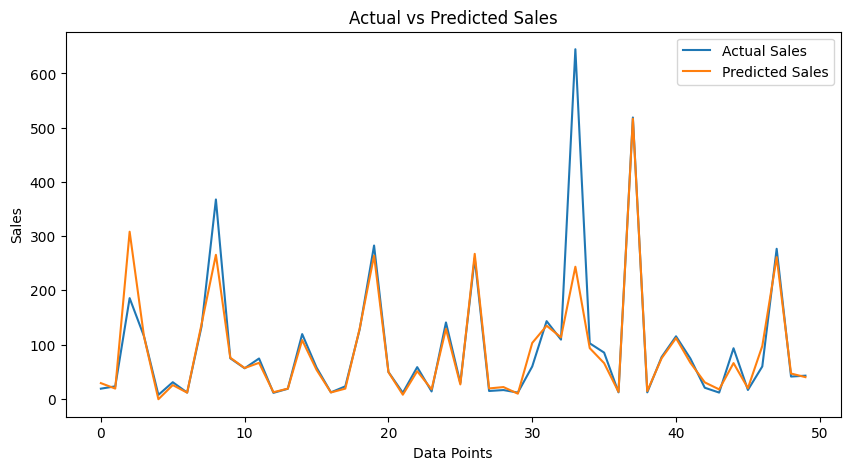

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(y_test.values[:50], label='Actual Sales')

plt.plot(predictions[:50], label='Predicted Sales')

plt.legend()

plt.title("Actual vs Predicted Sales")

plt.xlabel("Data Points")

plt.ylabel("Sales")

plt.show()

In [16]:
# historical trend analysis

import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("cleaned_sales_data.csv")
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year

In [22]:
print(df.columns)
df.columns = df.columns.str.strip()
print(df.columns)
monthly_sales = df.groupby('Month')['Total_Sales'].sum()

print(monthly_sales)

Index(['TransactionNo', 'Date', 'ProductNo', 'ProductName', 'Price',
       'Quantity', 'CustomerNo', 'Country', 'Total_Sales', 'Month', 'Year'],
      dtype='str')
Index(['TransactionNo', 'Date', 'ProductNo', 'ProductName', 'Price',
       'Quantity', 'CustomerNo', 'Country', 'Total_Sales', 'Month', 'Year'],
      dtype='str')
Month
1.0     1524500.65
2.0     1240970.60
3.0     1490119.05
4.0     1407503.16
5.0     1968052.68
6.0     1678676.22
7.0     1522160.93
8.0     2228230.74
9.0     2118254.35
10.0    2905243.86
11.0    3483465.84
12.0    5129321.82
Name: Total_Sales, dtype: float64


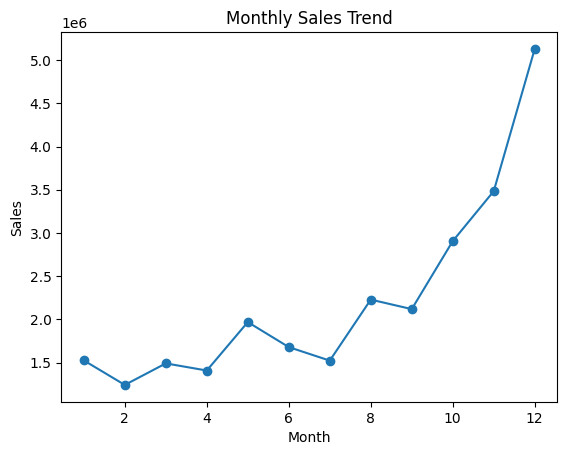

In [23]:
#monthly sales trend analysis
import matplotlib.pyplot as plt

monthly_sales.plot(kind='line', marker='o')

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.show()

In [24]:
best_month = monthly_sales.idxmax()

print("Best Sales Month:", best_month)

Best Sales Month: 12.0


In [ ]:
#revenue prediction

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
df = pd.read_csv("cleaned_sales_data.csv")
df.columns = df.columns.str.strip()
df['Revenue'] = df['Quantity'] * df['Price']
X = df[['Quantity', 'Price']]
y = df['Revenue']

#model aplit and train

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
model = LinearRegression()

model.fit(X_train, y_train)

#predict revenue

predictions = model.predict(X_test)

print(predictions)

#checking accuracy
score = model.score(X_test, y_test)

print("Model Accuracy:", score)

#prediction of future revenue

Revenue = model.predict([[15, 200]])

print("Predicted Revenue:", Revenue)



[  4.23881885 134.14965012  36.90726959 ...  26.96255231 466.29436896
   1.56080972]
Model Accuracy: 0.96909764289189
Predicted Revenue: [649.03827856]


c:\Users\Zarna\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


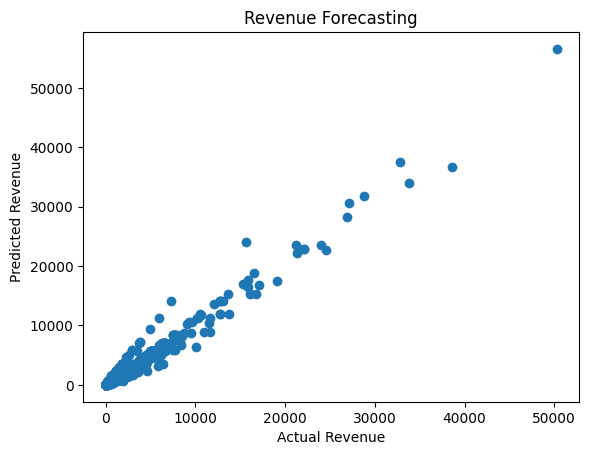

In [32]:
#visulisation for predicting revenue

plt.scatter(y_test, predictions)

plt.xlabel("Actual Revenue")
plt.ylabel("Predicted Revenue")

plt.title("Revenue Forecasting")

plt.show()

Total Quantity Sold: 5574850
Total Revenue: 62781386.54
Average Price: 12.637155483522834
Highest Revenue: 1002718.1000000001


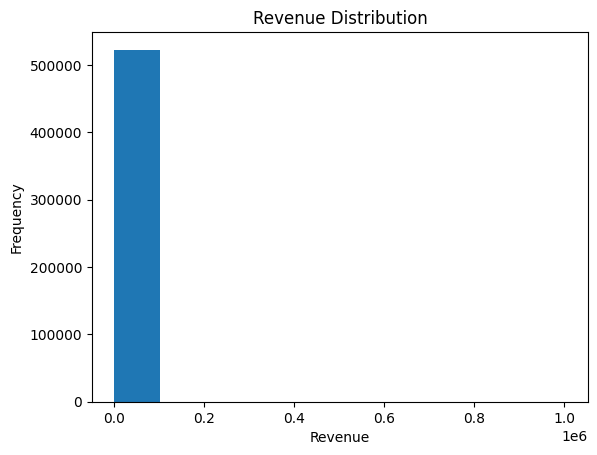

Month
1.0     1524500.65
2.0     1240970.60
3.0     1490119.05
4.0     1407503.16
5.0     1968052.68
6.0     1678676.22
7.0     1522160.93
8.0     2228230.74
9.0     2118254.35
10.0    2905243.86
11.0    3483465.84
12.0    5129321.82
Name: Revenue, dtype: float64


In [38]:
#Intelligent KPI Monitoring

total_revenue = df['Revenue'].sum()
total_quantity = df['Quantity'].sum()

print("Total Quantity Sold:", total_quantity)

print("Total Revenue:", total_revenue)
average_price = df['Price'].mean()

print("Average Price:", average_price)
max_revenue = df['Revenue'].max()

print("Highest Revenue:", max_revenue)

#kpi visualisation

df['Revenue'].plot(kind='hist', bins=10)

plt.title("Revenue Distribution")
plt.xlabel("Revenue")

plt.show()

df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.month
monthly_revenue = df.groupby('Month')['Revenue'].sum()

print(monthly_revenue)

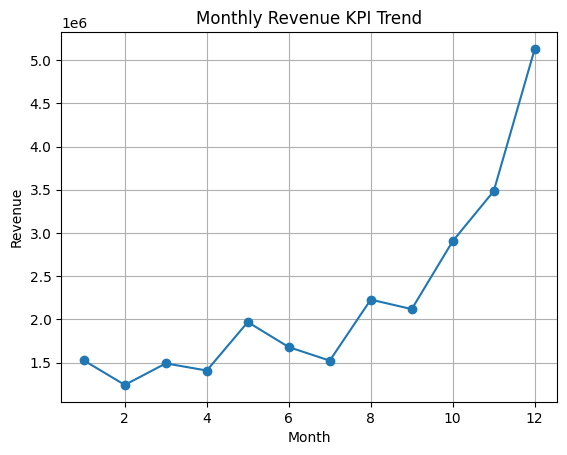

In [39]:
import matplotlib.pyplot as plt

monthly_revenue.plot(kind='line', marker='o')

plt.title("Monthly Revenue KPI Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.grid(True)

plt.show()

In [37]:
df['Month'] = df['Date'].dt.month

df['Revenue'] = df['Quantity'] * df['Price']

# FIX DATA TYPES
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')

df['Quantity'] = pd.to_numeric(df['Quantity'], errors='coerce')

df['Revenue'] = pd.to_numeric(df['Revenue'], errors='coerce')

# REMOVE EMPTY VALUES
df = df.dropna()

X = df[['Price', 'Quantity', 'Month']]

y = df['Revenue']

df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['Month'] = df['Date'].dt.month
df = df.dropna()
print(df[['Price', 'Quantity', 'Month', 'Revenue']].isnull().sum())


Price       0
Quantity    0
Month       0
Revenue     0
dtype: int64


In [38]:
#Data-Driven Business Insights
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

X = df[['Price', 'Quantity', 'Month']]

y = df['Revenue']

In [39]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [41]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

predictions = model.predict(X_test)

print(predictions[:10])

score = model.score(X_test, y_test)

print("Accuracy:", score)

[ 30.25051324  20.36411303 308.5854687  116.2008124   -0.32664742
  27.16515075  12.96153232 137.91724976 264.36361111  76.68483838]
Accuracy: 0.9821126724626138


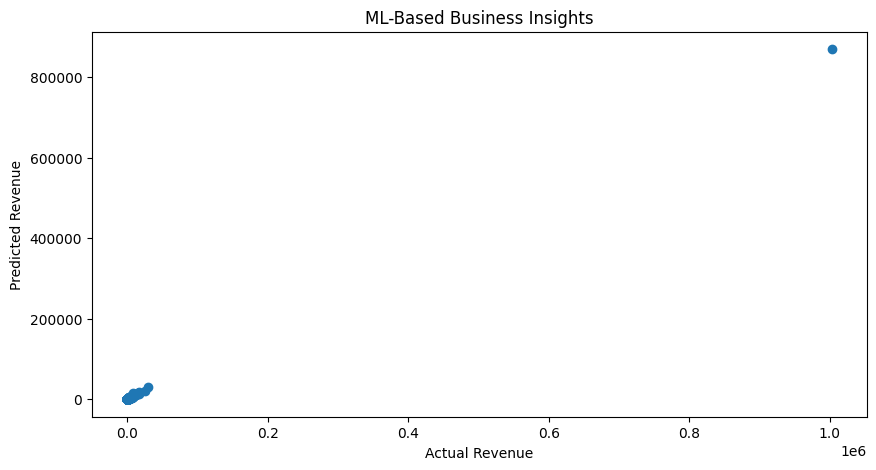

In [42]:
#data driven business insights ML 
#visualizations
plt.figure(figsize=(10,5))

plt.scatter(y_test, predictions)

plt.xlabel("Actual Revenue")

plt.ylabel("Predicted Revenue")

plt.title("ML-Based Business Insights")

plt.show()

In [50]:
#intelligent KPI Monitoring

df['Month'] = df['Date'].dt.month

df['Revenue'] = df['Quantity'] * df['Price']

df = df.dropna()

X = df[['Quantity', 'Price', 'Month']]

y = df['Revenue']

#spli and train
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
model = LinearRegression()

model.fit(X_train, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [52]:
#predict and accuracy
predictions = model.predict(X_test)

print(predictions[:10])
score = model.score(X_test, y_test)

print("KPI Prediction Accuracy:", score)

[ 30.25051324  20.36411303 308.5854687  116.2008124   -0.32664742
  27.16515075  12.96153232 137.91724976 264.36361111  76.68483838]
KPI Prediction Accuracy: 0.9821126724626391


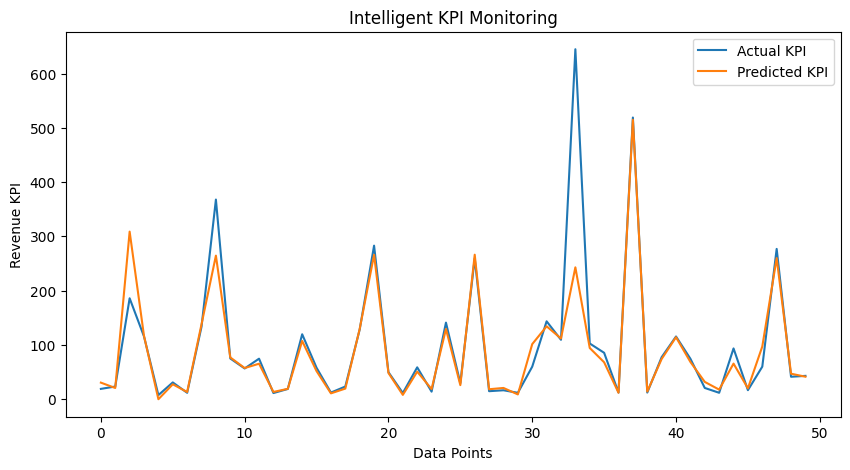

In [53]:
#KPI trend Visualization
plt.figure(figsize=(10,5))

plt.plot(y_test.values[:50], label='Actual KPI')

plt.plot(predictions[:50], label='Predicted KPI')

plt.legend()

plt.title("Intelligent KPI Monitoring")

plt.xlabel("Data Points")

plt.ylabel("Revenue KPI")

plt.show()